# Autoencoder para Detección de Fraude con Tarjetas de Crédito

Este notebook implementa un autoencoder en TensorFlow para el dataset de fraude [link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data).

In [61]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from matplotlib import pyplot as plt

## Cargar dataset

In [2]:
df = pd.read_csv('../data/creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values per column:
Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
V11       0
V10       0
V9        0
V8        0
V7        0
V6        0
V5        0
V4        0
V3        0
V2        0
Class     0
dtype: int64


In [5]:
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True).rename('proportion'))


Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [6]:
X = df.drop('Class', axis=1).values
y = df['Class'].values

## Preprocesamiento

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## División de train/test y selección de datos normales

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_normal = X_train[y_train == 0]

## Modelo Autoencoder

In [28]:
input_dim = X_train_normal.shape[1]
inputs = tf.keras.Input(shape=(input_dim,))
encoded = tf.keras.layers.Dense(16, activation='relu')(inputs)
encoded = tf.keras.layers.Dense(8, activation='relu')(encoded)

bottleneck = tf.keras.layers.Dense(4, activation='relu')(encoded)

decoded = tf.keras.layers.Dense(8, activation='relu')(bottleneck)
decoded = tf.keras.layers.Dense(16, activation='relu')(decoded)
outputs = tf.keras.layers.Dense(input_dim, activation='linear')(decoded)
autoencoder = tf.keras.Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

## Entrenamiento

In [29]:
history = autoencoder.fit(X_train_normal, X_train_normal, epochs=20, batch_size=256, validation_split=0.1, shuffle=True)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.9162 - val_loss: 0.7199
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7189 - val_loss: 0.6598
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6617 - val_loss: 0.6341
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6407 - val_loss: 0.6164
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6172 - val_loss: 0.5985
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6023 - val_loss: 0.5861
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5966 - val_loss: 0.5725
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5790 - val_loss: 0.5634
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5758 - val_loss: 0.5546
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5623 - val_loss: 0.5484
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5584 - val_loss: 0.5427
Epoch 12/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

## Errores de reconstrucción y umbral

7108/7108 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


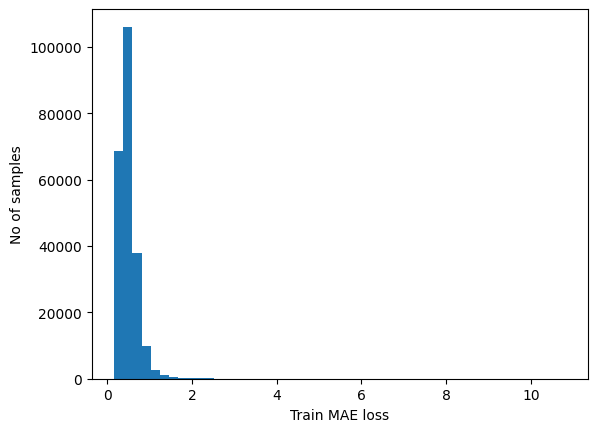

In [38]:
x_train_pred = autoencoder.predict(X_train_normal)
train_mae_loss = np.mean(np.abs(x_train_pred - X_train_normal), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("No of samples")
plt.show()

In [50]:
threshold = np.quantile(train_mae_loss, [0.99])[0]
threshold

1.2397182184440179

In [51]:
X_test_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.abs(X_test - X_test_pred), axis=1)



1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [52]:
reconstruction_error

array([6.07825074, 0.6349466 , 0.36933303, ..., 0.58056754, 0.33557509,
       0.80942264])

## Clasificación y métricas

In [53]:
y_pred = (reconstruction_error > threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.79      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.89      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [54]:
print(confusion_matrix(y_test, y_pred))

[[56283   581]
 [   21    77]]


In [59]:
y_pred = (reconstruction_error > 0.5).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.61      0.76     56864
           1       0.00      0.98      0.01        98

    accuracy                           0.61     56962
   macro avg       0.50      0.79      0.38     56962
weighted avg       1.00      0.61      0.75     56962



In [60]:
print(confusion_matrix(y_test, y_pred))

[[34513 22351]
 [    2    96]]
